In [1]:
import numpy as np
import pandas as pd
import math
import heapq

In [2]:
a = pd.read_csv("./datasets/a280.csv")
a = pd.read_csv("./minidatasets/minitsp.csv")
points = np.array(a[['x','y']])
inputsize = len(points)

In [3]:
# distance matrix 만들기
diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
distance_matrix = np.sqrt(np.sum(diff ** 2, axis=-1))

In [4]:
# MST 찾기( 프림 알고리즘 사용)
visited = [False] * len(points)
minheap = []
mstgraph = np.full( ( inputsize, inputsize ), np.inf)

# 0 추가
for x in range(inputsize):
    heapq.heappush(minheap, ( distance_matrix[0][x] , 0, x ) )
visited[ 0 ] = True

while minheap:
    Weight, From, To = heapq.heappop( minheap )
    if not visited[To]:
        visited[To] = True
        mstgraph[ From, To ] = Weight
        mstgraph[ To, From ] = Weight
        for x in range(inputsize):
            next_to, next_weight = x, distance_matrix[To][x]
            if not visited[ next_to ]:
                heapq.heappush( minheap, ( next_weight, To, next_to ) )

mstgraph

array([[        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,  7.07106781,         inf,         inf,         inf,
                inf,  8.06225775,         inf,         inf,         inf],
       [        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
         8.54400375,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,  9.05538514,         inf],
       [        inf,         inf,         inf,         inf,         inf,
                inf,         inf,         inf,   

In [5]:
# 홀수 degree 찾기
oddmat = np.full( ( inputsize, inputsize ), np.inf)

finite_mask = np.isfinite(mstgraph)              # inf가 아닌 값은 True
finite_count_per_row = finite_mask.sum(axis=1) # 각 행마다 inf가 아닌 값의 개수
odd_rows = np.where(finite_count_per_row % 2 == 1)[0]  # 개수가 홀수인 행 인덱스

print(odd_rows.tolist())

[4, 7, 9, 10, 14, 15, 16, 18, 20, 28]


In [6]:
# minimum weight perfect matching Blossom 알고리즘
dual = np.full( ( inputsize, inputsize ), np.inf)
primal = np.full( ( inputsize, inputsize ), np.inf)

print(distance_matrix[np.ix_(odd_rows, odd_rows)])
len(distance_matrix[np.ix_(odd_rows, odd_rows)])

[[ 0.         33.24154028 14.2126704  11.18033989 14.56021978 16.2788206
  14.76482306 31.90611227 25.05992817 25.45584412]
 [33.24154028  0.         45.61797891 23.70653918 46.27094121 29.69848481
  39.20459157 52.20153254 36.89173349 30.41381265]
 [14.2126704  45.61797891  0.         21.9317122  15.8113883  20.02498439
  24.08318916 38.83297568 23.70653918 27.89265136]
 [11.18033989 23.70653918 21.9317122   0.         25.70992026 10.
  23.43074903 40.31128874 20.02498439 17.4642492 ]
 [14.56021978 46.27094121 15.8113883  25.70992026  0.         29.68164416
  11.40175425 23.19482701 36.76955262 38.83297568]
 [16.2788206  29.69848481 20.02498439 10.         29.68164416  0.
  30.8058436  48.01041554 10.04987562  9.21954446]
 [14.76482306 39.20459157 24.08318916 23.43074903 11.40175425 30.8058436
   0.         17.20465053 39.8246155  39.8246155 ]
 [31.90611227 52.20153254 38.83297568 40.31128874 23.19482701 48.01041554
  17.20465053  0.         56.93856338 57.00877125]
 [25.05992817 36.8

10

In [7]:
# # (u, v, weight)
# next_Id = len( distance_matrix ) + 1

# class node:
#     def __init__(self, Id, indices):
#         self.nid = Id
#         self.tid = Id # 필요한가?? 흠
#         self.dist = [ (to, distance_matrix[Id][to]) for to in indices if to != Id]
#         self.dual = 0
#         self.matching = None
#         self.visited = False
#         self.label = None
        
#     def is_blossom(self):
#         return False
    
#     def distance(self, v):
#         for i, j in self.dist:
#             if i == v.nid:
#                 return j
#         return -1
                
#     def slack(self, v):
#         d = self.distance(v)
#         return d - v.dual - self.dual

# class blossom(node):
#     def __init__(self, cycle):
#         self.nid = next_Id
#         next_Id += 1

#         self.leaves = cycle
        
#     def is_blossom(self):
#         return True

#     def distance(self, v):
#         m = np.inf
#         for x in self.cycle:
#             m = min( m, x.distance(v) )
#         return m

#     def slack(self, v):
#         d = self.distance(v)
#         return d - v.dual - self.dual


# class tree: #사실 트리임
#     def __init__(self, G ,indices=None):
#         if indices is not None:
#             self.nodes = [ node( Id, indices ) for Id in indices ]
#             self.root = None
#     def add_node(self, u):
#         self.nodes.append(u)
#     def add_edge(self, e):
#         u,v,w = e
#         u.dist.append( (v.Id, w) )
#     def distance(self, u, v):
#         return u.distance(v)
#     def slack(self, u, v):
#         return u.slack(v)
#     def tightnode(self,u):
#         return [ node for node in self.nodes if self.slack(u, node) == 0 ]



# class blossomgraph:
#     def __init__(self, indices):
#         self.nodes = [ node( Id, indices ) for Id in indices ]
#         self.tree = None
#         # self.edges = [ ( u, v, distance_matrix[u, v]) for u in indices for v in indices if u < v ]
#     def distance(self, u, v):
#         return u.distance(v)
#     def slack(self, u, v):
#         return u.slack(v)
#     def tightnode(self,u):
#         return [ node for node in self.nodes if self.slack(u, node) == 0 ]
#     def mktree(self, root):
#         return
        
#     def GROW(self, u, v):
#         v.label = not u.label
#         v.visited = True
#         v.matching.label = u.label
#         v.matching.visited = True
#         return
#     def AUGMENT(self,u,v):
#         return
#     def SHRINK(self,u,v):
#         return
#     def EXPAND(self,u,v):
#         return
#     def dualupdate():
#         return

#     def find_min_weight_matching(self):
#         #init dual - greedy
#         # 최소거리의 절반으로 먼저 셋팅함
#         for node in self.nodes:
#             m = np.inf
#             for To in self.nodes:
#                 if To == node:
#                     continue
#                 if m > node.distance(To):
#                     m = node.distance(To)
#             node.dual = m / 2
            
#         # 그리디하게 최대화해두자
#         for node in self.nodes:
#             m = np.inf
#             closestnode = node
#             for To in self.nodes:
#                 if To == node:
#                     continue
#                 if m > node.slack(To):
#                     m = node.slack(To)
#                     closestnode = To
#             node.dual += m
#             if node.matching == None and closestnode.matching ==None:
#                 node.matching = closestnode
#                 closestnode.matching = node

#         def init_nodes():
#             for node in self.nodes:
#                 node.label = None
#                 node.visited = False


#         # anode # 매칭 없는 짜바리 찐따임
#         # bfs(anode) #anode 부터 bfs 돌아버림 돌때, tight 한거만.
#         queue = []
#         init_nodes()
#         for node in self.nodes:
#             if node.matching is not None:
#                 queue.append( node )
#                 node.visited = True
#                 node.label = True # +
#                 break

#         while len(queue):
#             curnode = queue[0]
#             for node in self.tightnode(curnode):
#                 if not node.visited:
#                     queue.append(node)
#                     node.visited=True
#                     node.label = not curnode.label
#                 else:
#                     #싸이클인디요?
#                     None
            

            
#             del queue[0]
            
            
        
        
#         return

# g = blossomgraph(odd_rows)
# a = g.nodes[3]
# b = g.nodes[7]
# g.find_min_weight_matching()


In [8]:
# # 오일러 회로 찾기
# # np.where( odd_rows == 1 )[0][0]
# for x in range( len( g.nodes ) ):
#     if g.nodes[x].matching != None:
#         print( g.nodes[x].nid, g.nodes[x].matching.nid , g.nodes[x] == g.nodes[x].matching.matching )

In [9]:
# for x in g.tightnode(a):
#     print(x.nid)

In [10]:
# # shortcutting
# for i in g.nodes:
#     for j in g.nodes:
#         if i == j:
#             continue
#         print( i.nid, j.nid, g.slack(i,j))

In [11]:
# import matplotlib.pyplot as plt
# import networkx as nx

# # position 딕셔너리 생성
# pos = {node.nid: points[node.nid] for node in g.nodes}

# plt.figure(figsize=(10,10))

# for node in g.nodes:
#     x, y = pos[node.nid]
#     radius = node.dual
#     circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
#     plt.gca().add_patch(circle)
#     plt.plot(x, y, 'ro')  # 노드 위치 표시

# plt.title('Graph nodes with dual value as radius')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.axis('equal')
# plt.grid(True)
# plt.show()


In [12]:
import matplotlib.pyplot as plt

# # position 딕셔너리 생성
# pos = {node.nid: points[node.nid] for node in g.nodes}

# plt.figure(figsize=(10,10))

# # 1. 매칭 간선 먼저 그리기 (두꺼운 선)
# drawn = set()
# for node in g.nodes:
#     match = node.matching
#     # 매칭이 있고, 아직 그리지 않은 쌍만 그림
#     if match is not None and (node.nid, match.nid) not in drawn and (match.nid, node.nid) not in drawn:
#         x1, y1 = pos[node.nid]
#         x2, y2 = pos[match.nid]
#         plt.plot([x1, x2], [y1, y2], color='k', linewidth=4)  # 두꺼운 검은선
#         drawn.add((node.nid, match.nid))

# # 2. 각 노드의 원과 점 그리기
# for node in g.nodes:
#     x, y = pos[node.nid]
#     radius = node.dual
#     circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
#     plt.gca().add_patch(circle)
#     plt.plot(x, y, 'ro')  # 노드 위치 표시

# plt.title('Graph nodes with dual value as radius and matching edges')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.axis('equal')
# plt.grid(True)
# plt.show()

# def visualize():
#     # position 딕셔너리 생성
#     pos = {node.nid: points[node.nid] for node in g.nodes}
    
#     plt.figure(figsize=(10,10))
    
#     # 1. 매칭 간선 먼저 그리기 (두꺼운 선)
#     drawn = set()
#     for node in g.nodes:
#         match = node.matching
#         # 매칭이 있고, 아직 그리지 않은 쌍만 그림
#         if match is not None and (node.nid, match.nid) not in drawn and (match.nid, node.nid) not in drawn:
#             x1, y1 = pos[node.nid]
#             x2, y2 = pos[match.nid]
#             plt.plot([x1, x2], [y1, y2], color='k', linewidth=4)  # 두꺼운 검은선
#             drawn.add((node.nid, match.nid))
    
#     # 2. 각 노드의 원과 점 그리기
#     for node in g.nodes:
#         x, y = pos[node.nid]
#         radius = node.dual
#         circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
#         plt.gca().add_patch(circle)
#         plt.plot(x, y, 'ro')  # 노드 위치 표시
    
#     plt.title('Graph nodes with dual value as radius and matching edges')
#     plt.xlabel('X')
#     plt.ylabel('Y')
#     plt.axis('equal')
#     plt.grid(True)
#     plt.show()

# visualize()

In [13]:
# 모든 노드는 블라썸 노드로 생각 할 수 있다.
# 사이즈가 1 이면 일반노드, 3 이상의 홀수 노드이면 블라썸이 되는 것.
# 이떄, 
# 1. 블라썸은 자기에 포함된 노드를 가지고 있어야한다.
# 2. 엣지도 알고 있어야한다.
# 3. 블라썸이 생길떄 전체 그래프에서 노드와 엣지를 추가/삭제 해야함.

# 그리고 트리를 관리해야함. 트리는 루트를 알고 있어야하고, 트리의 구성을 알기위해서 어떻게 연결되었는지 찾을 수 있어야함. 맞나?
# 한놈을 고르고 그놈이 augment 될떄까지 그놈만 패면 되니까.
# 트리를 관리하지 말고 한놈을 잡고 그놈이 매칭될때 까지 패면 될듯함.
next_id = len(distance_matrix)


class blossom:
    def __init__(self, G, Id, nodes=None, edges=None):
        self.Graph = G
        self.Id = Id
        self.Dual = 0
        self.Matching = None
        self.Nodes = []
        self.Edges = []
        
        self.Visited = False
        self.Label = None
        self.parent = None
        self.child = []
        
        if nodes != None:
            self.Nodes += nodes
        if edges != None:
            self.Edges += edges
        
    def is_blossom(self):
        if len(self.Nodes) >= 3:
            return True
        return False
        
    def add_node(self, v):
        self.Nodes.append(v)
    def add_edge(self, e):
        self.Edges.append(e)
        
    def distance(self, v):
        return self.Graph.distance(self,v)
        
    def slack(self, v):
        return self.Graph.slack(self,v)
    def mark(self):
        self.Visited = True
        if self.parent is None:
            self.Label = True
        else:
            self.Label = not self.parent.Label



        

# 트리를 그래프가 하나만 가지고 있고
# 트리는 루트만 가지고 있음 그리고
# 각 노드는 자식과 부모를 알고 있다.
# priaml operation 은 여기에다가 하면 될듯

class blossomgraph:
    def __init__(self, indices):
        self.nodes = [ blossom( self, Id ) for Id in indices ]  # nodes 먼저 생성하고
        self.edges = []
        
        for n1 in self.nodes:
            for n2 in self.nodes:
                if n1.Id >= n2.Id:
                    continue
                self.edges.append( ( n1, n2, distance_matrix[n1.Id][n2.Id] ) ) # (u,v, weight)

        self.alt_tree = [] # 트리 안에 있는 노드만 기록
        
    def distance(self, u, v):
        for n1, n2, w in self.edges:
            if (u,v) == (n1,n2) or (v,u) == (n1,n2):
                return w
        return -1
        
    def slack(self, u, v):
        return self.distance(u,v) - u.Dual - v.Dual
    def tightnode(self,u):
        return [ node for node in self.nodes if self.slack(u, node) <= 1.0e-8 and u != node]

    def init_nodes(self):
        for node in self.nodes:
            node.Visited = False
            node.Label = None
            node.parent = None
            node.child = []

    def connect(self,u,v):
        u.Matching = v
        v.Matching = u

    def find_cycle(self, u,v):
        upath =[]
        vpath = []
        upath.append(u)
        vpath.append(v)
        
        cur = u
        while cur.parent != None:
            upath.append( cur.parent )
            cur = cur.parent

        cur = v
        while cur.parent != None:
            vpath.append( cur.parent )
            cur = cur.parent

        cycle = []
        for uindex in range(len(upath)):
            if upath[uindex] in vpath:
                break
        target = upath[uindex]
        cur = u
        while cur != target:
            cycle.append( cur )
            cur = cur.parent

        cur = v
        while cur != target:
            cycle.append( cur )
            cur = cur.parent

        cycle.append(target)
        return cycle            

    def SHRINK(self,cycle): # 내부 엣지는 숨기기만 하면 되고, 외부와 연결된 엣지는 숨기고, dual 값 뺴서 외부와 연결시켜야함
        global next_id
        newblossom = blossom(self, next_id, cycle)
        self.nodes.append(newblossom)
        next_id += 1
        for node in cycle:
            self.nodes.remove(node)

        deledges = []
        for edge in self.edges: # 내부 엣지부터 처리
            u,v,w = edge
            uin = u in cycle
            vin = v in cycle
            if not (uin or vin):
                continue
            if uin and  vin: #내부 엣지
                newblossom.add_edge( edge ) #블라썸에 저장해두고
                deledges.append(edge)
                # self.edges.remove( edge )          #그래프에서는 삭제
                continue

            if uin and not vin: #외부 엣지임
                newblossom.add_edge(edge)                           #블라썸에 저장해두고
                deledges.append(edge)
                # self.edges.remove(edge)                              #그래프에서 제거하고
                self.edges.append( ( newblossom, v, w - u.Dual ) )    #바꿔서 그래프에 추가
                continue
                
            if not uin and vin:
                newblossom.add_edge(edge)                           #블라썸에 저장해두고
                deledges.append(edge)
                # self.edges.remove(edge)                              #그래프에서 제거하고
                self.edges.append( ( newblossom, u, w - v.Dual ) )    #바꿔서 그래프에 추가
                continue
        for e in deledges:
            self.edges.remove(e)

        for node in self.nodes:
            if newblossom == node:
                continue
            if node.Matching in cycle:
                node.Matching.Matching = None
                self.connect(node, newblossom)

    def aug_connect(self, u, v):
        if u.is_blossom():
            m = np.inf
            target = None
            vedge1 = [ e for e in u.Edges if e[0] == v ]
            vedge2 = [ e for e in u.Edges if e[1] == v ]
            for e in vedge1:
                if m > e[2]:
                    m = e[2]
                    target = e[1]
            for e in vedge2:
                if m > e[2]:
                    m = e[2]
                    target = e[0]
                    
            nextnode = target.Matching
            curnode = None
            prevnode = None
            self.aug_connect(target , v)
            while nextnode == None:
                prevnode = curnode
                curnode = nextnode
                for e in u.Edges:
                    nextnode = curnode
                
                
            
        if v.is_blossom():
            print(1)
        # 둘다 블라썸 아닌거이까
        self.connect(u,v)

    def EXPAND(self, blossom, v): #가지고 있던거 밖으로 다 던지고, 그래프에 blossom 적인거 다 지우면 됌.
        #원복
        for node in blossom.Nodes:
            self.nodes.append(node)
        for edge in blossom.Edges:
            self.edges.append(edge)

        self.aug_connect(blossom, v)
        return
    

    def bfs(self, root): #bfs 하고 cycle 생기면 블라썸 만들어버리는 것 까지. grow augment shrink expand
        self.init_nodes()
        self.alt_tree.clear()
        queue = []
        root.mark()
        queue.append(root)
        self.alt_tree.append(root)
        print("root id : ", root.Id)
        while queue:
            curnode = queue.pop(0) # + 인 애들임
            print("curnode : ",curnode.Id)
            for node in self.tightnode(curnode):
                print("tight node : ", node.Id)
                if node.Label == False and node.Dual == 0 and node.is_blossom(): # expand
                    print("expand")
                    return
                if node.Label == None and node.Matching == None: # augment
                    print("augment")
                    parent = curnode
                    cur = node
                    
                    while 1:
                        self.aug_connect(parent,cur)
                        
                        cur = parent.parent
                        if cur is None:
                            break                        
                        parent = cur.parent

                    self.alt_tree = []
                    return True
                    


                if node.Label == None and node.Matching != None: # grow
                    print("grow")
                    curnode.child.append(node)
                    node.child.append( node.Matching )
                    
                    node.parent = curnode
                    node.Matching.parent = node
    
                    queue.append(node.Matching)
                    self.alt_tree.append(node)
                    self.alt_tree.append(node.Matching)
                    node.mark()
                    node.Matching.mark()
                if node.Label == True: # shrink
                    print("shrink")
                    
                    cycle = self.find_cycle(curnode, node)
                    print("==============")
                    for node in cycle:
                        print(node.Id)
                    self.SHRINK(cycle)
                    
                    return
        return False

    def updatedual(self):
        delta = np.inf
        pnodes = [ node for node in self.alt_tree if node.Label == True ]
        blossom = [ node for node in self.alt_tree if node.is_blossom() and node.Label == False]
        freenodes = [ node for node in self.nodes if node.Label == None ]
        #case 1 트리안의 + 노드와 외부의 모든 노드간의 최소 slack 에 닿게 하기
        for n1 in pnodes:
            for n2 in freenodes:
                if delta > self.slack( n1, n2):
                    delta = self.slack( n1, n2)
                    print("min is ", n1.Id, n2.Id)
        #case 2 트리 안의 + 노드간 slack의 절반
        for n1 in pnodes:
            for n2 in pnodes:
                if n1 == n2:
                    continue
                if delta > self.slack( n1, n2) / 2 :
                    delta = self.slack( n1, n2) /2
                    print("min is ", n1.Id, n2.Id)
        #case 3
        for b1 in blossom:
            if delta > b1.Dual:
                    delta = self.slack
                    print("min is ", n1.Id, n2.Id)

        for node in self.alt_tree:
            if node.Label == True:
                node.Dual += delta
            else:
                node.Dual -= delta
            
            
            

    def find_min_weight_matching(self):
        #init dual - greedy
        # 최소거리의 절반으로 먼저 셋팅함
        for node in self.nodes:
            m = np.inf
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.distance(To):
                    m = node.distance(To)
            node.Dual = m / 2
            
        # 그리디하게 최대화해두자
        for node in self.nodes:
            m = np.inf
            closestnode = node
            for To in self.nodes:
                if To == node:
                    continue
                if m > node.slack(To):
                    m = node.slack(To)
                    closestnode = To
            node.Dual += m
            if node.Matching == None and closestnode.Matching ==None:
                node.Matching = closestnode
                closestnode.Matching = node

        return

f = blossomgraph(odd_rows)
f.find_min_weight_matching()


In [14]:
def visualize():
    # position 딕셔너리 생성
    pos = {node.Id: points[node.Id] for node in f.nodes}
    
    plt.figure(figsize=(10,10))
    
    # 1. 매칭 간선 먼저 그리기 (두꺼운 선)
    drawn = set()
    for node in f.nodes:
        match = node.Matching
        # 매칭이 있고, 아직 그리지 않은 쌍만 그림
        if match is not None and (node.Id, match.Id) not in drawn and (match.Id, node.Id) not in drawn:
            x1, y1 = pos[node.Id]
            x2, y2 = pos[match.Id]
            plt.plot([x1, x2], [y1, y2], color='k', linewidth=4)  # 두꺼운 검은선
            drawn.add((node.Id, match.Id))
    
    # 2. 각 노드의 원과 점 그리기
    for node in f.nodes:
        x, y = pos[node.Id]
        radius = node.Dual
        circle = plt.Circle((x, y), radius, color='b', fill=False, alpha=0.5)
        plt.gca().add_patch(circle)
        plt.plot(x, y, 'ro')  # 노드 위치 표시
        plt.text(
            x, y,                      # 텍스트 위치
            str(node.Id),              # 그릴 내용
            fontsize=12,               # 글자 크기
            ha='right',                # 수평 정렬: 오른쪽
            va='bottom',               # 수직 정렬: 아래쪽
            color='black'              # 글자 색상
        )
    
    plt.title('Graph nodes with dual value as radius and matching edges')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid(True)
    plt.show()

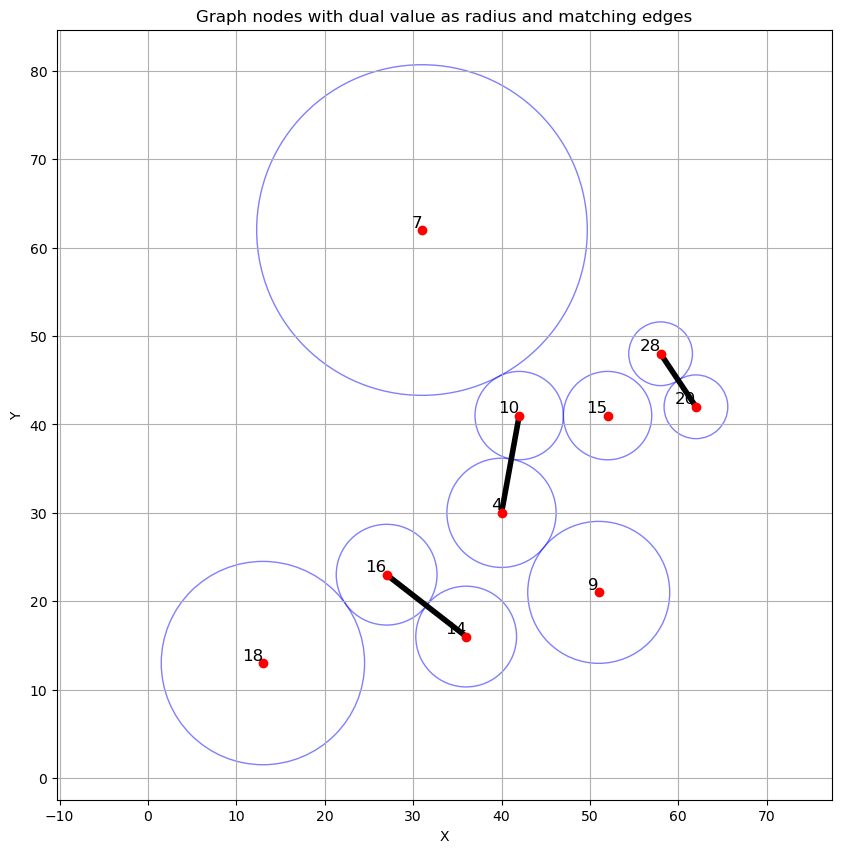

4 False
7 False
9 False
10 False
14 False
15 False
16 False
18 False
20 False
28 False


In [15]:
visualize()
for node in f.nodes:
    print(node.Id, node.is_blossom())

root id :  7
curnode :  7
tight node :  10
grow
curnode :  4
tight node :  9
augment


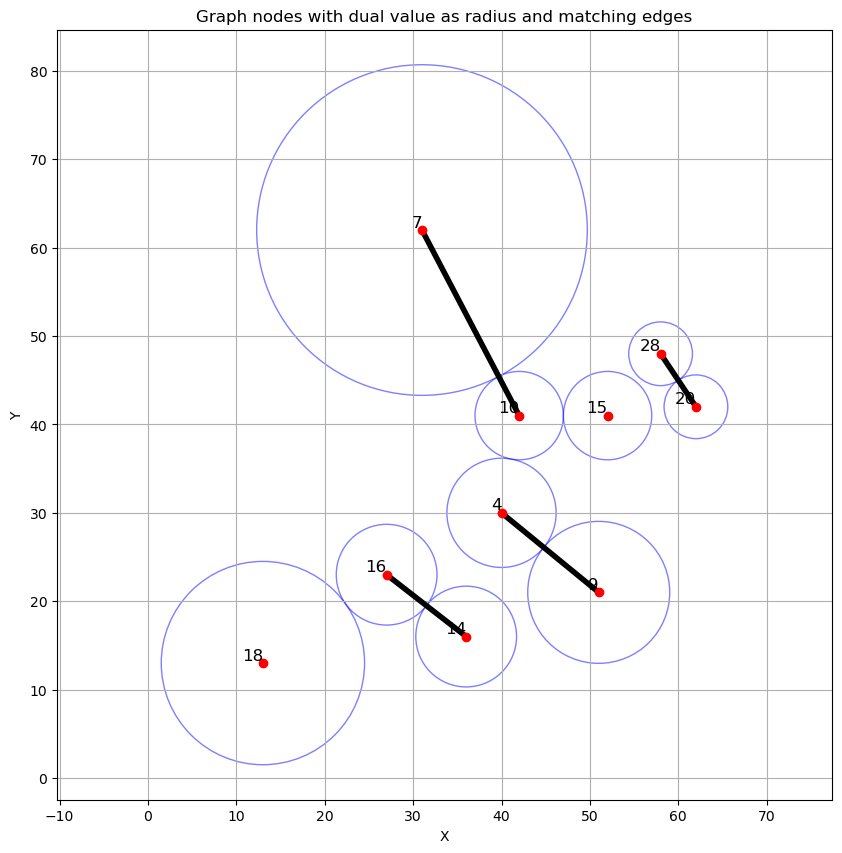

In [16]:
x = f.nodes[1]
if x.Matching is None:
    f.bfs(x)
    visualize()
for x in f.alt_tree:
    print(x.Id)

root id :  15
curnode :  15
tight node :  10
grow
curnode :  7
tight node :  10


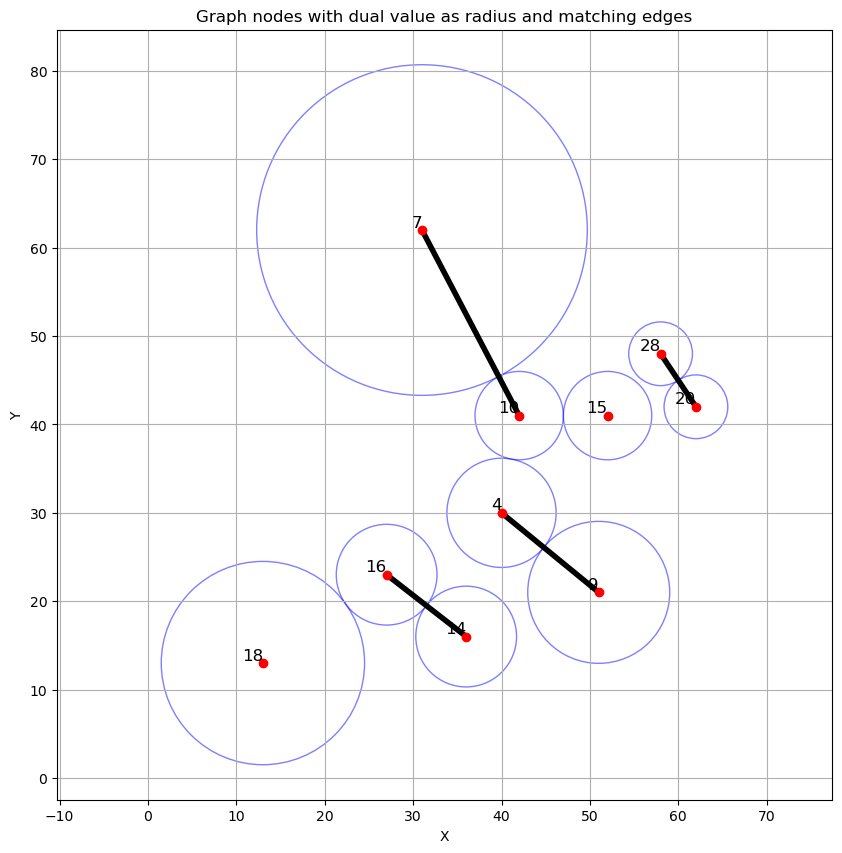

15 True
10 False
7 True


In [17]:
x = f.nodes[5]
if x.Matching is None:
    f.bfs(x)
    visualize()
for x in f.alt_tree:
    print(x.Id, x.Label)

min is  15 4
min is  15 20
min is  15 28


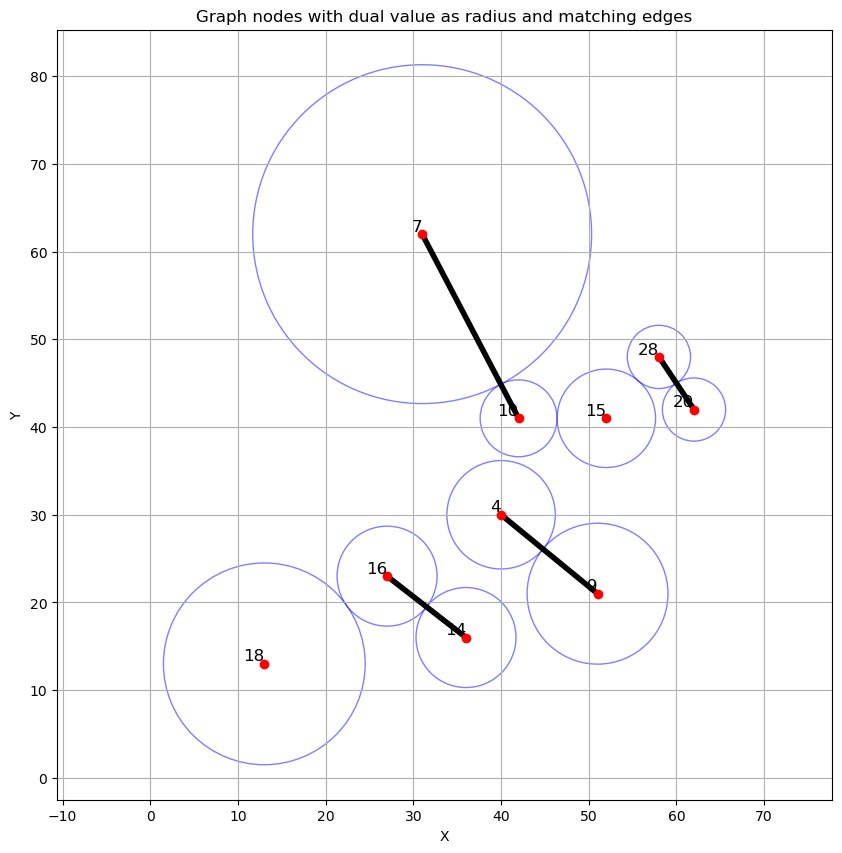

In [18]:
f.updatedual()
visualize()

root id :  7
curnode :  7
tight node :  10
grow
curnode :  7
tight node :  10


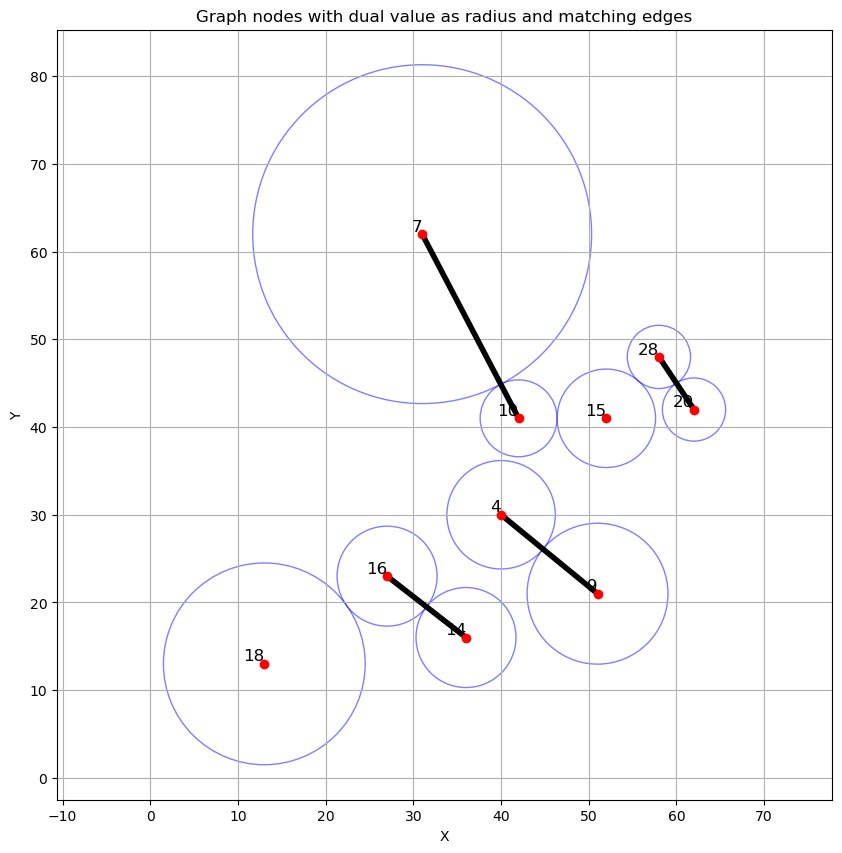

In [19]:
f.bfs(x)
visualize()

In [20]:
f.tightnode( x )
for node in f.nodes:
    if node == x:
        continue
    print(f.slack(node, x))

f.tightnode(x)

7.74066802560208
18.265116031686937
0.0
21.249531715453116
4.763959263917805
14.183182078241337
21.377226771874888
13.96564985184115
7.487729011938818


In [21]:
[ node for node in f.nodes if f.slack(x, node) <= 0 and x != node][0].Id

10

In [22]:
x.Id

7

In [23]:
f.nodes[9].Id

28

In [24]:
f.slack(x, f.nodes[9])

7.487729011938816

In [25]:
f.nodes[5].Id

15

In [26]:
f.bfs( f.nodes[5] )

root id :  15
curnode :  15
tight node :  10
grow
tight node :  28
grow
curnode :  7
tight node :  10
curnode :  20
tight node :  28


False

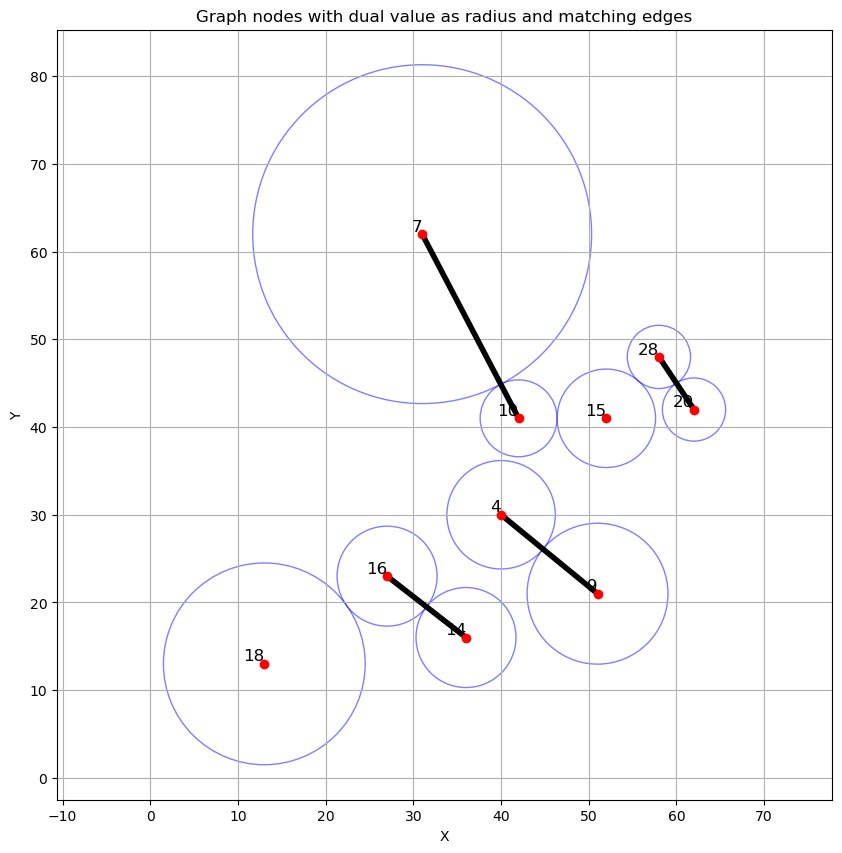

min is  15 4
min is  15 7
min is  15 20
min is  20 15


In [27]:
visualize()
f.updatedual()

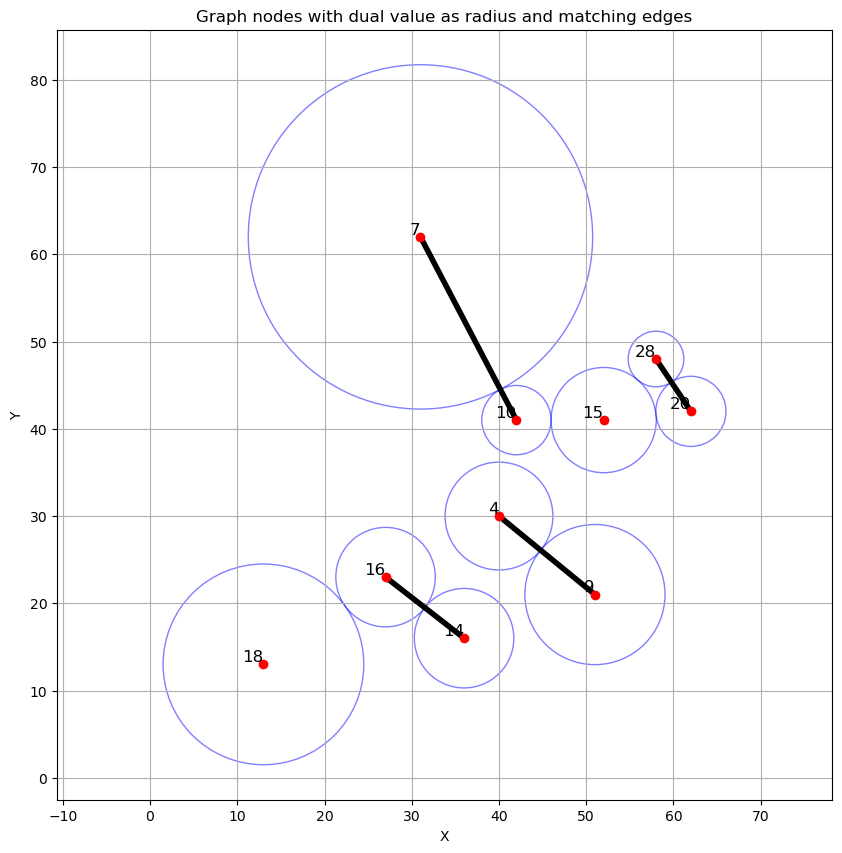

In [28]:
visualize()

In [29]:
f.updatedual()
f.slack(x, f.nodes[9])

min is  15 4
min is  15 7
min is  15 20


7.487729011938814

In [30]:
print(f.nodes[9].Dual)
print(f.nodes[5].Dual)
print(f.distance(f.nodes[5], f.nodes[9]))
print(f.slack(f.nodes[5], f.nodes[9]))

3.1903856935499877
6.029158763742899
9.219544457292887
4.440892098500626e-16


In [31]:
f.tightnode( f.nodes[5] )

root id :  18
curnode :  18
tight node :  16
grow
curnode :  14
tight node :  16
min is  18 4
min is  14 4
min is  14 9


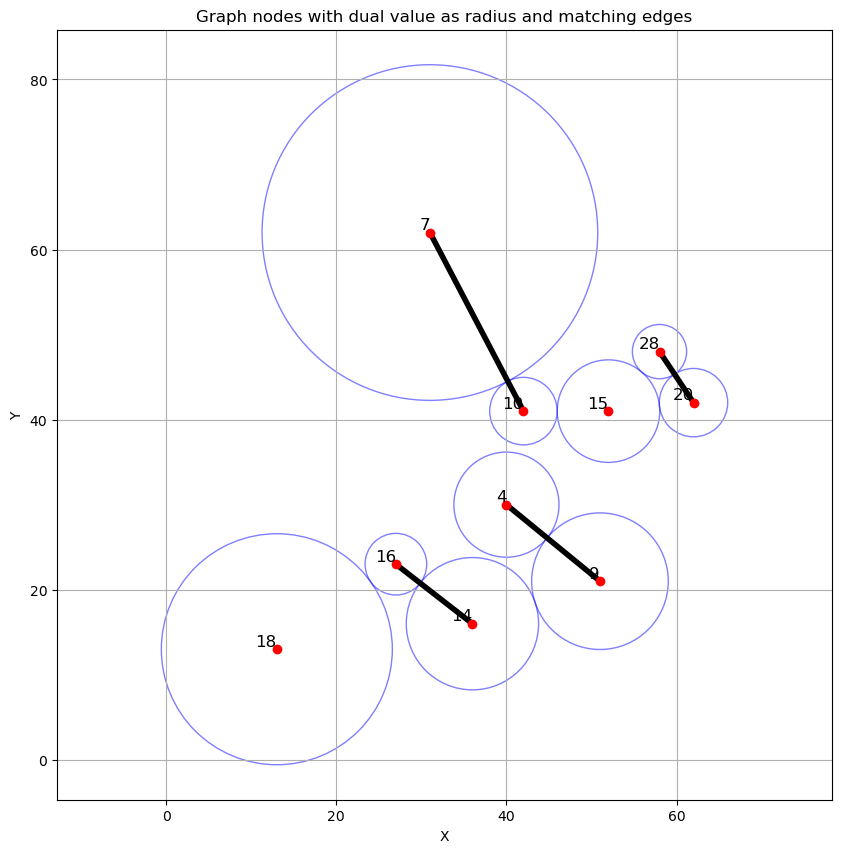

In [32]:
for node in f.nodes:
    if node.Id == 18:
        break
f.bfs(node)
f.updatedual()
visualize()

root id :  18
curnode :  18
tight node :  16
grow
curnode :  14
tight node :  9
grow
tight node :  16
curnode :  4
tight node :  9
min is  18 7
min is  14 7
min is  14 10
min is  4 7
min is  4 10
min is  18 14
min is  14 4


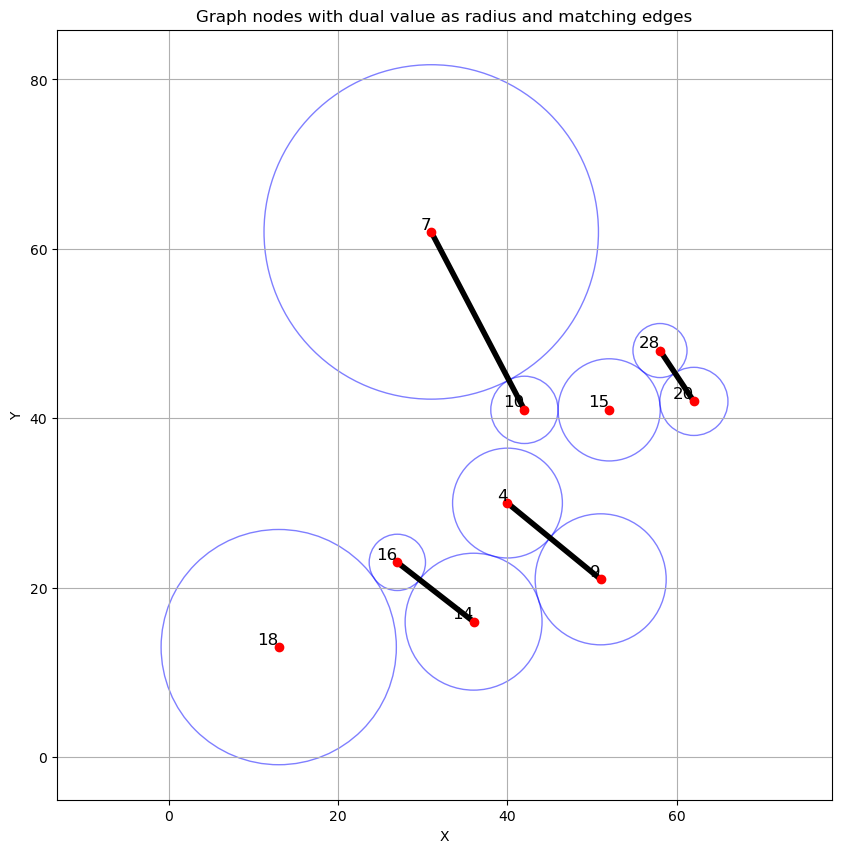

In [33]:
f.bfs(node)
f.updatedual()
visualize()

In [34]:
f.bfs(node)
f.tightnode(node)

root id :  18
curnode :  18
tight node :  16
grow
curnode :  14
tight node :  4
grow
tight node :  9
shrink
9
4
14


In [35]:
for node in f.nodes:
    print(node.Id, node.is_blossom())

7 False
10 False
15 False
16 False
18 False
20 False
28 False
30 True


In [36]:
f.alt_tree

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def visualize(f, points):
    """
    f      : blossomgraph 인스턴스
    points : 각 원래 노드(Id)에 대응하는 (x, y) 좌표를 담은 dict 또는 배열
    """
    # 1) 노드별 위치 계산(pos): 블라썸이면 포함된 노드들의 평균 위치
    pos = {}
    for node in f.nodes:
        if node.is_blossom():
            xs = [points[n.Id][0] for n in node.Nodes]
            ys = [points[n.Id][1] for n in node.Nodes]
            pos[node.Id] = (np.mean(xs), np.mean(ys))
        else:
            pos[node.Id] = tuple(points[node.Id])

    plt.figure(figsize=(10, 10))

    # 2) 매칭 간선 먼저 그리기 (두꺼운 검은 선)
    drawn = set()
    for node in f.nodes:
        match = node.Matching
        if match is not None and (node.Id, match.Id) not in drawn:
            x1, y1 = pos[node.Id]
            x2, y2 = pos[match.Id]
            plt.plot([x1, x2], [y1, y2],
                     color='k', linewidth=4)
            drawn.add((node.Id, match.Id))
            drawn.add((match.Id, node.Id))

    # 3) 노드(원 + 점 + 아이디) 그리기
    ax = plt.gca()
    for node in f.nodes:
        x, y = pos[node.Id]
        radius = node.Dual
        circle = plt.Circle((x, y), radius,
                            color='b', fill=False, alpha=0.5)
        ax.add_patch(circle)
        plt.plot(x, y, 'ro')
        plt.text(x, y, str(node.Id),
                 fontsize=12, ha='right', va='bottom',
                 color='black')

    plt.title('Graph nodes with dual value as radius and matching edges')
    plt.xlabel('X'); plt.ylabel('Y')
    plt.axis('equal'); plt.grid(True)
    plt.show()


root id :  18
curnode :  18
tight node :  16
grow
curnode :  30
min is  18 7
min is  30 7
min is  30 10


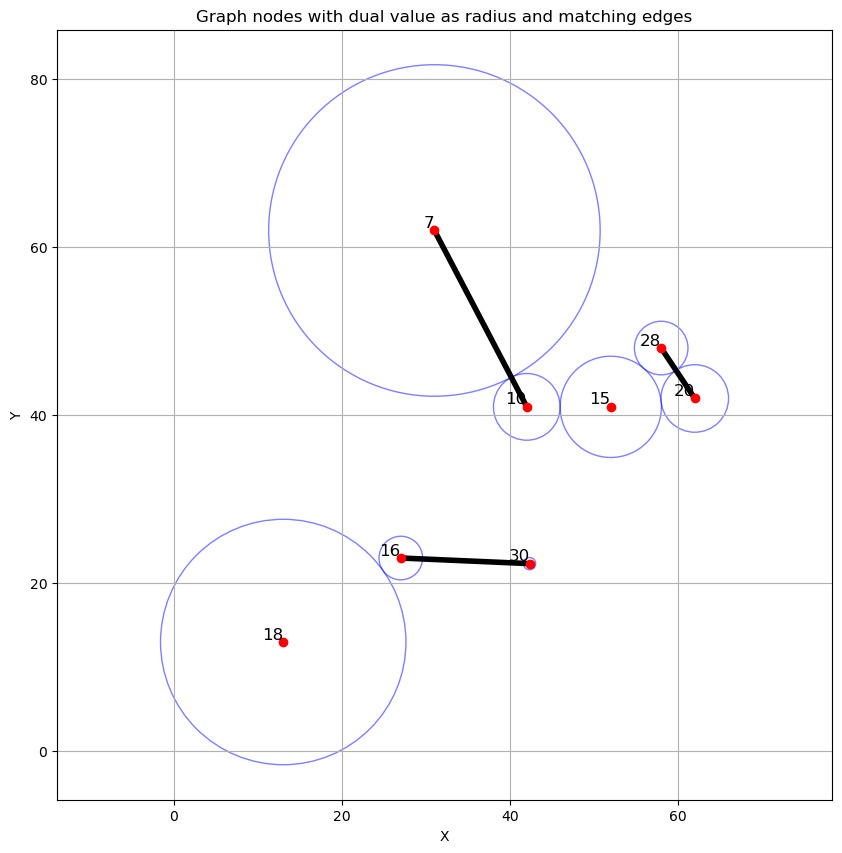

In [41]:
f.bfs(f.nodes[4])
f.updatedual()
visualize(f, points)

root id :  18
curnode :  18
tight node :  16
grow
curnode :  30
tight node :  10
grow
curnode :  7
tight node :  10
min is  18 15
min is  30 15


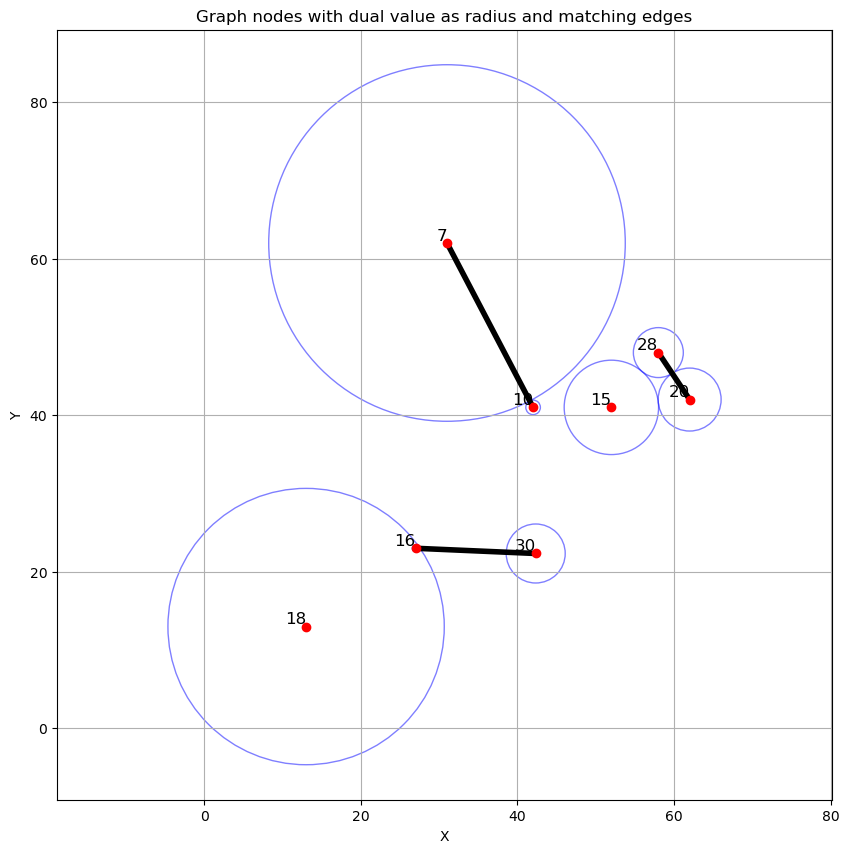

In [42]:
f.bfs(f.nodes[4])
f.updatedual()
visualize(f, points)

root id :  18
curnode :  18
tight node :  16
grow
curnode :  30
tight node :  10
grow
tight node :  15
augment


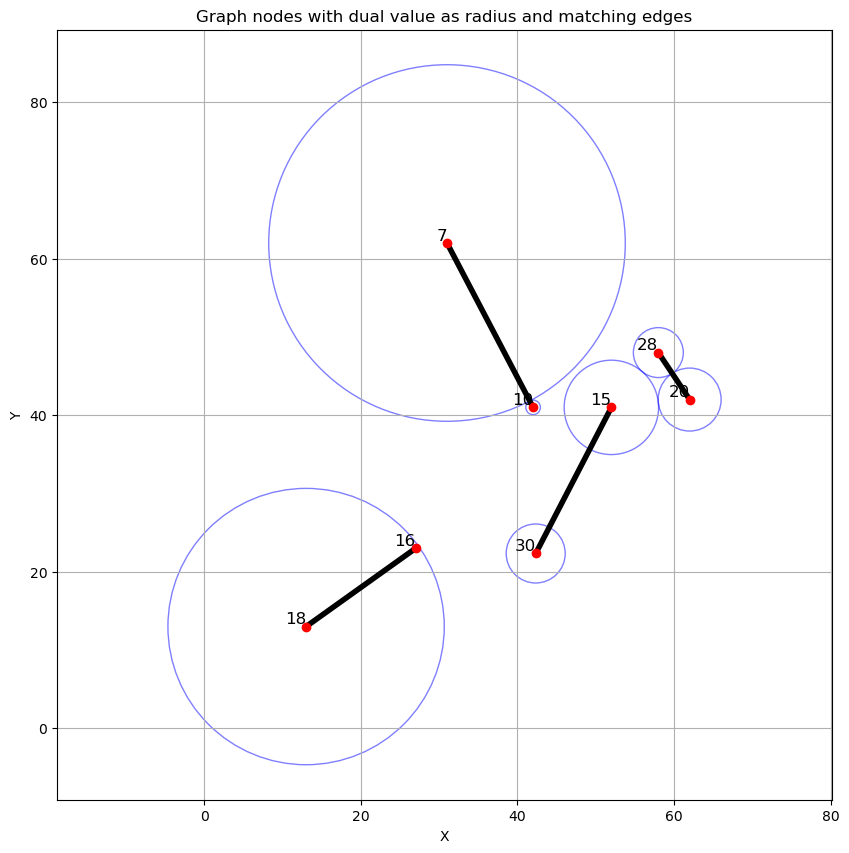

In [43]:
f.bfs(f.nodes[4])
f.updatedual()
visualize(f, points)

root id :  18
curnode :  18
tight node :  16
grow
curnode :  18
tight node :  16
min is  18 7
min is  18 30


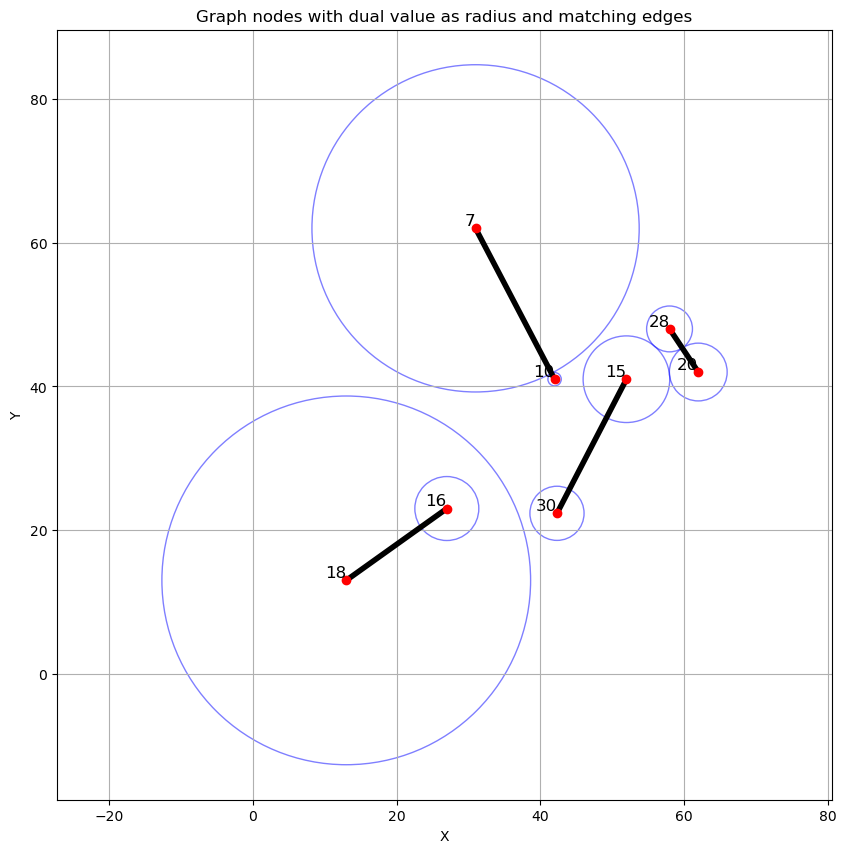

In [44]:
f.bfs(f.nodes[4])
f.updatedual()
visualize(f, points)

In [45]:
f.bfs(f.nodes[4])
f.updatedual()
visualize(f, points)

root id :  18
curnode :  18
tight node :  16
grow
tight node :  30
grow
curnode :  18
tight node :  16
tight node :  30
curnode :  15
tight node :  20
grow
tight node :  28
shrink



KeyboardInterrupt



In [ ]:
f.bfs(f.nodes[4])
f.updatedual()
visualize(f, points)